# HSSM in thirty minutes

**Day 3, 09:30 — 30 minutes.** Alexander Fengler.

Yesterday you built a DDM likelihood into a PyMC model by hand. HSSM is the
layer that does that for you — and then lets you put a **regression on any
parameter**, swap the likelihood for a **neural approximation**, or bring your
own network entirely.

Thirty minutes buys three things:

1. the shortest possible working model, and the two defaults that will burn
   you if you do not know them,
2. the SSM-specific fit checks,
3. how to plug in a likelihood **you** trained.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import hssm
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-hssm"))

print("hssm", hssm.__version__)
print("built-in models:", len(hssm.list_models()))

hssm 0.4.0
built-in models: 16


## 1. The shortest model that works

In [2]:
data = hssm.load_data("cavanagh_theta")
print(data.head(5).to_string(index=False))
print(f"\n{len(data)} trials, {data['participant_id'].nunique()} participants")
print("response values:", sorted(data["response"].unique()))

 participant_id stim   rt  response     theta  dbs conf
              0   LL 1.21       1.0  0.656275    1   HC
              0   WL 1.63       1.0 -0.327889    1   LC
              0   WW 1.03       1.0 -0.480285    1   HC
              0   WL 2.77       1.0  1.927427    1   LC
              0   WW 1.14      -1.0 -0.213236    1   HC

3988 trials, 14 participants
response values: [np.float64(-1.0), np.float64(1.0)]


::: {.callout-warning}
## Two defaults that fail silently

**1. Responses are coded `-1` / `+1`, not `0` / `1`.** A value outside the
model's choice set raises. A *valid but mis-coded* `0`/`1` does not raise — it
quietly mismodels the start-point bias and hands you a clean-looking, wrong
posterior.

**2. `p_outlier` defaults to `0.05`.** Every model you fit has a 5% lapse
mixture in it unless you say otherwise. That is a defensible default and a
terrible surprise. State it explicitly in your code and in your paper, or
switch it off with `p_outlier=None`.
:::

In [3]:
model = hssm.HSSM(data=data, model="ddm", p_outlier=0.05)
print(model)

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 3988

Parameters:

v:
    Prior: Normal(mu: 0.0, sigma: 2.0)
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)


`print(model)` is the single most useful HSSM command: it resolves and shows
every prior, every bound, the link functions, and the lapse process. Read it
before you sample, every time.

In [4]:
idata = model.sample(draws=500, tune=500, chains=2, cores=1,
                     random_seed=RANDOM_SEED, progressbar=False)
print(type(idata).__name__)

Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [z, a, t, v]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 26 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


DataTree


::: {.callout-important}
## `model.summary()` and `model.plot_trace()` are gone in HSSM 0.4.0
Both now raise `NotImplementedError`. Use ArviZ directly on `model.traces`,
naming the variables you want — otherwise you get one deterministic node *per
trial per parameter* and an unreadable table.
:::

In [5]:
PARAMS = ["v", "a", "z", "t"]
print(az.summary(model.traces, var_names=PARAMS, kind="stats").to_string())

   mean      sd eti89_lb eti89_ub
v  0.39    0.02     0.36     0.42
a   1.1  0.0087      1.1      1.1
z   0.5  0.0061     0.49     0.51
t  0.35  0.0053     0.34     0.36


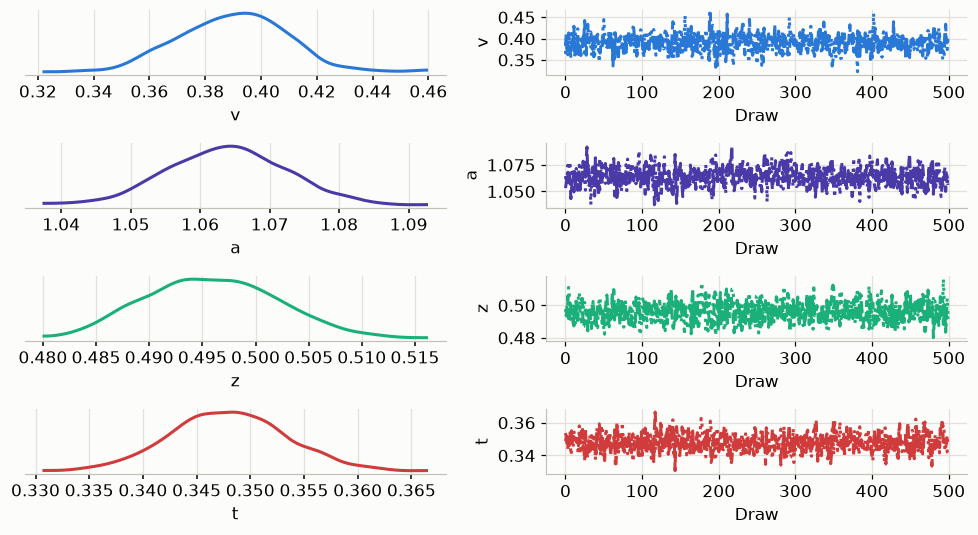

In [6]:
az.plot_trace_dist(model.traces, var_names=PARAMS, combined=True)
plt.gcf().set_size_inches(9, 5)
plt.tight_layout()

## 2. The fit checks that are specific to SSMs

A trace plot tells you the sampler behaved. It says nothing about whether the
*model* describes the data. For sequential-sampling models there are two
checks worth knowing.

dt=None, we use the traces assigned to the HSSM object as datatree.


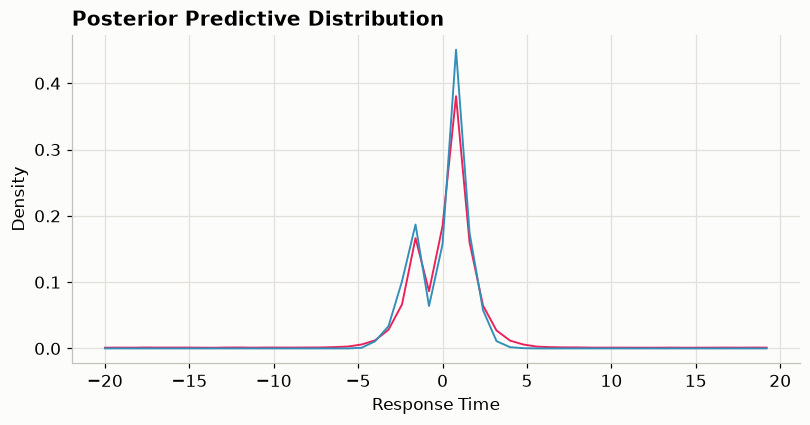

In [7]:
# draws=100 is deliberate. The default regenerates a response for EVERY posterior
# draw x every trial -- here 1000 x 3988, about 100 seconds -- while both plots
# below consume only `n_samples=20`. Capping it costs nothing and saves ~80s.
model.sample_posterior_predictive(kind="response", draws=100)
model.plot_predictive()
plt.gcf().set_size_inches(7.5, 4)
plt.tight_layout()

The **quantile probability plot** is the field standard: RT quantiles on the
y-axis against choice proportion on the x-axis, so speed and accuracy are
visible in one picture, split by condition.

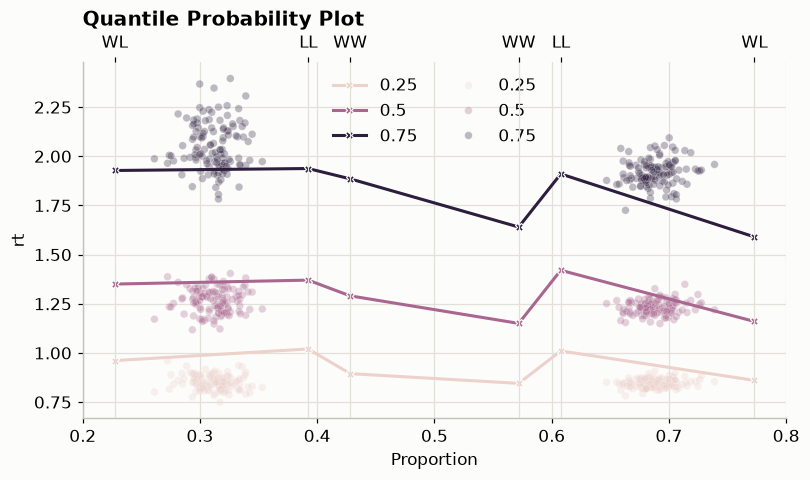

In [8]:
model.plot_quantile_probability(cond="stim")
plt.gcf().set_size_inches(7.5, 4.5)
plt.tight_layout()

> **Poll.** Your posterior predictive RT densities match the data well, but
> the quantile probability plot is off in the slowest quantile. What is the
> most likely culprit?
>
> **A.** The sampler did not converge.
> **B.** Too few posterior predictive draws.
> **C.** The boundary is wrong — a constant bound cannot produce that tail shape.
> **D.** The non-decision time prior is too tight.

<details>
<summary>Answer</summary>

**C.** The slow tail is where boundary shape shows up. A constant-bound DDM
produces a specific tail; if the data's tail is shorter, a **collapsing**
bound (`angle`, `weibull`) is the usual fix. Aggregate densities can look fine
while the conditional structure is wrong — which is exactly why the quantile
probability plot exists.

</details>

## 3. Bring your own likelihood

The analytic DDM likelihood exists in closed form. Most interesting models do
not have one. HSSM's answer: **train a neural network to approximate the
likelihood, export it to ONNX, and hand HSSM the file.**

In [9]:
lan_model = hssm.HSSM(
    data=data,
    model="ddm",
    loglik_kind="approx_differentiable",   # neural backend
    p_outlier=0.05,
)
print("bounds (= the network's training region):")
for param, bound in lan_model.model_config.bounds.items():
    print(f"   {param:6s} {bound}")

Model initialized successfully.


bounds (= the network's training region):
   v      (-3.0, 3.0)
   a      (0.3, 2.5)
   z      (0.0, 1.0)
   t      (0.0, 2.0)


::: {.callout-important}
## The single most important guardrail in the ecosystem
For an `approx_differentiable` model, **the bounds *are* the region the
network was trained on.** Push a parameter outside — directly, or through a
regression whose linear predictor wanders out — and the network extrapolates.
You get a finite, plausible, **wrong** log-likelihood. No warning, no error.

Compare the numbers above with the analytic DDM's bounds: `v` is
`(-inf, inf)` analytically but `(-3, 3)` for the network. Always check
`model.model_config.bounds` before setting your own priors.
:::

Fitting it is the same call as before, with one rule: a JAX-backed LAN wants
the **numpyro** sampler, and in a notebook keep `cores=1, chains=1` or native
NUTS can raise cloudpickle errors.

```python
lan_model.sample(sampler="numpyro", draws=500, tune=500, chains=1, cores=1)
```

We do not run it here — it is the same machinery you already saw, and the
minutes are better spent on the next section, where the likelihood is *yours*
rather than one HSSM downloaded for you.

### Your own network — the JAX route, no ONNX, no torch

There are two ways to bring your own likelihood in. Start with the one that
needs **nothing extra installed**.

HSSM will accept a plain **JAX function** as the likelihood. The contract is
the same single-trial shape as ONNX:

> `f(data_i, *params) -> scalar`, where `data_i` is that trial's
> `[rt, choice]`. HSSM `jax.vmap`s it over trials and differentiates it for you.

This matters because **BayesFlow's default Keras backend is JAX** — including
in this environment — so a trained approximator's `log_prob` already *is* a
JAX function. You can hand it straight over.

Below, a hand-written surrogate stands in for that trained network, so the
demo runs in seconds. The plumbing is identical.

In [10]:
import jax.numpy as jnp
from hssm.config import ModelConfig

SIGMA = 0.45

def single_trial_logp(data, v, a, z, t):
    """Stand-in for a trained network's log_prob: lognormal RT x biased choice.

    Smooth and finite everywhere in the parameter box — see the gotchas below
    for why that is not optional.
    """
    rt, ch = data[0], data[1]
    mu = jnp.log(a) - jnp.log(v**2 + 0.25) + t
    lr = jnp.log(jnp.maximum(rt, 1e-6))
    logp_rt = -lr - jnp.log(SIGMA) - 0.5 * jnp.log(2 * jnp.pi) \
        - 0.5 * ((lr - mu) / SIGMA) ** 2
    drive = 2.0 * v * a + 4.0 * (z - 0.5)
    p_up = 1.0 / (1.0 + jnp.exp(-drive))
    return logp_rt + jnp.where(ch > 0, jnp.log(p_up), jnp.log1p(-p_up))


sim = hssm.simulate_data(model="ddm", theta=[0.9, 1.3, 0.5, 0.3], size=600,
                         random_state=RANDOM_SEED)

cfg = ModelConfig(
    response=["rt", "response"],
    list_params=["v", "a", "z", "t"],
    choices=(-1, 1),
    bounds={"v": (-3.0, 3.0), "a": (0.3, 2.5), "z": (0.1, 0.9), "t": (0.0, 1.0)},
    backend="jax",
)

jax_model = hssm.HSSM(
    data=sim,
    model="my_jax_surrogate",              # unrecognised name -> custom mode
    model_config=cfg,
    loglik=single_trial_logp,              # a plain JAX function
    loglik_kind="approx_differentiable",
    p_outlier=0,
)
jax_model.sample(sampler="numpyro", draws=500, tune=500, chains=2, cores=1,
                 random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(jax_model.traces, var_names=PARAMS, kind="stats").to_string())
print("\ntrue values: v=0.9  a=1.3  z=0.5  t=0.3")
print("divergences:", int(jax_model.traces.sample_stats["diverging"].values.sum()))

You supplied a model 'my_jax_surrogate', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


Using default initvals. 



NUTS[numpyro]: [z, a, t, v]


There were 245 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


   mean    sd eti89_lb eti89_ub
v  0.94  0.15     0.63      1.2
a   1.2  0.27     0.71      1.6
z  0.46   0.2     0.16     0.82
t  0.24  0.13    0.017     0.43

true values: v=0.9  a=1.3  z=0.5  t=0.3
divergences: 245


Parameters recover, and **torch was never installed**. That is the whole
point: if your network already lives in JAX, ONNX is an unnecessary hop.

Those divergences are worth a moment. They are not a plumbing failure — they
are my surrogate's own geometry. Look at `mu`: `a`, `v` and `t` all push the
same location, so the three trade off along a ridge. **Yesterday afternoon's
lesson applies to surrogates too** — a badly conditioned likelihood is badly
conditioned no matter who wrote it.

::: {.callout-warning}
## Three things that will freeze your chain
**Your function must be finite at HSSM's initial values.** HSSM initialises
drift at `v = 0`. A surrogate taking `log(|v|)` is `-inf` there, the chain
starts at `-inf`, and every draw diverges with the posterior pinned to the
initval. This looks like a broken sampler and is a broken likelihood.

**Every parameter you declare must actually enter the function.** A parameter
the function ignores has an identically-zero gradient — a perfectly flat
direction NUTS cannot integrate.

**Fixing a parameter (`t=0.3`) does not currently work with
`backend="jax"`** — it raises an `AssertionError` in pytensor's `specifyshape`
JAX dispatch. Keep parameters free, or narrow their bounds instead.
([HSSM #1092](https://github.com/lnccbrown/HSSM/issues/1092))
:::

### Exercise — break it on purpose

The failure modes above are much easier to recognise once you have caused one.
Take `single_trial_logp`, delete `z` from the body (leave it in the signature),
refit, and look at the posterior for `z` and at the divergence count.

Predict first: what will the `z` posterior look like?

<details>
<summary>What happens, and why it is worth seeing once</summary>

```python
def broken_logp(data, v, a, z, t):            # z accepted but never used
    rt, ch = data[0], data[1]
    mu = jnp.log(a) - jnp.log(v**2 + 0.25) + t
    lr = jnp.log(jnp.maximum(rt, 1e-6))
    logp_rt = -lr - jnp.log(SIGMA) - 0.5*jnp.log(2*jnp.pi) - 0.5*((lr-mu)/SIGMA)**2
    p_up = 1.0 / (1.0 + jnp.exp(-2.0*v*a))    # no z
    return logp_rt + jnp.where(ch > 0, jnp.log(p_up), jnp.log1p(-p_up))
```

Every draw diverges and the posterior collapses to a point — `sd` of exactly
`0` on every parameter, not just on `z`. It looks like a catastrophic sampler
failure, and the cause is one unused argument.

The reason the whole model freezes rather than just `z` going flat: `z` has an
identically-zero gradient, so the leapfrog integrator cannot make progress in
that coordinate at any step size, and the trajectory is rejected wholesale.

The general lesson for surrogate likelihoods: **a parameter your network does
not actually condition on is not merely unidentified — it is actively toxic to
a gradient sampler.** Declare only the parameters your likelihood uses.

</details>

### The other route: ONNX, for cross-framework artifacts

Use ONNX when the network must outlive the framework that trained it, or when
it came from PyTorch/sbi rather than JAX. The contract is deliberately narrow:

> The graph takes **one** rank-1 input vector of shape `(n_params + n_data,)`
> — parameters concatenated with that trial's `[rt, choice]` — and returns a
> scalar log-likelihood. **No `dynamic_axes`.** HSSM batches over trials
> itself with `jax.vmap`.

HSSM enforces this at load time and refuses anything with a symbolic input
dimension. That refusal is a feature: `jaxonnxruntime` bakes the
construction-time shapes into the traced closure, so a batched graph with any
batch-dependent intermediate (a normalizing flow's log-det accumulator, say)
would silently return wrong numbers instead of failing.

Once you have a `.onnx`, the gesture is identical no matter what trained it:

```python
model = hssm.HSSM(
    data=obs_data,
    model="ddm",
    loglik="path/to/my_network.onnx",       # <- the .onnx extension is detected
    loglik_kind="approx_differentiable",
    p_outlier=0,
)
```

For a model HSSM does not know, supply a `ModelConfig` giving `list_params`,
`choices`, `backend`, and — critically — `bounds` set to the **training box**.

### Exporting a BayesFlow network to ONNX

If you do want the portable artifact, the export goes through **LANfactory**:

```python
import os
os.environ["KERAS_BACKEND"] = "torch"     # BEFORE importing keras / bayesflow

from lanfactory.onnx import transform_bayesflow_to_onnx

transform_bayesflow_to_onnx(
    approximator,                 # a trained ContinuousApproximator (NLE)
    "ddm_nle.onnx",
    mode="nle",                   # or "nre" for a RatioApproximator
    example_theta_dim=4,          # len(list_params)
    example_x_dim=2,              # [rt, choice]
)
```

::: {.callout-important}
## This route requires torch, and there is no way around it
`transform_bayesflow_to_onnx` calls `torch.onnx.export`, which cannot trace a
JAX-backed Keras model. It checks `KERAS_BACKEND` and raises `RuntimeError` if
it is anything but `"torch"` — so you must set it **before** keras is imported,
and you must have torch installed.

LANfactory therefore pulls in torch, and is deliberately **not** part of this
workshop's shared environment. If you only need the likelihood inside HSSM,
use the JAX-callable route above and skip all of this. Reach for ONNX when the
artifact has to be portable — shared with collaborators, archived alongside a
paper, or produced by PyTorch/sbi rather than JAX in the first place.
:::

Two more export constraints, if you go this way:

- The CouplingFlow must be ONNX-friendly: `permutation=None`,
  `AffineTransform(clamp=False)` passed as an **instance**, `activation="silu"`
  (not `hard_silu`), and a trivial adapter.
- Leave `floatX` at its default `float64`. Flow exports can carry an int64
  sentinel that truncates to `-1` under float32 and corrupts the graph.

| | JAX callable | ONNX |
|---|---|---|
| extra install | none | torch (+ LANfactory) |
| works in this env | **yes** | no |
| portable artifact | no | **yes** |
| source frameworks | anything JAX (incl. BayesFlow) | BayesFlow, sbi, LANfactory, PyTorch |

## 4. Where this goes — regressions on parameters

The reason to use HSSM rather than hand-rolling PyMC is this: **any parameter
can carry a trial-level, hierarchical regression.**

```python
model = hssm.HSSM(
    data=data,
    model="ddm",
    include=[{
        "name": "v",
        "formula": "v ~ 1 + theta + (1|participant_id)",
        "link": "identity",
    }],
    noncentered=True,
    p_outlier=0.05,
    prior_settings="safe",
)
```

That says: drift rate depends on the trial-level covariate `theta`, with a
participant-specific intercept drawn from a population distribution. Which is
a hierarchical model — and hierarchical models have a posterior geometry that
will eat your sampler alive if you let it.

**That is the 11:00 session.**

## What to take away

- `hssm.HSSM(data, model="ddm")` is a complete model. `print(model)` before
  sampling, every time.
- Responses are `[-1, +1]`. `p_outlier` is `0.05` unless you say otherwise.
  Both fail quietly.
- `model.summary()` / `model.plot_trace()` are gone — use `az.*` on
  `model.traces` with explicit `var_names`.
- `plot_quantile_probability` is the SSM fit check; aggregate densities hide
  conditional misfit.
- Two ways to bring your own likelihood: a **JAX callable** (nothing extra to
  install, and BayesFlow already runs on the JAX backend) or **ONNX**
  (portable, but needs torch). Prefer the callable unless you need the artifact.
- Both share one contract: **single trial in, scalar out**. HSSM vmaps it.
- For neural likelihoods, **bounds are the training region**. Outside them the
  answer is wrong rather than absent.